In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset , DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [24]:
torch.manual_seed(42)

In [25]:
df = pd.read_csv('fmnist_small.csv')

In [26]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [27]:
df.shape

(6000, 785)

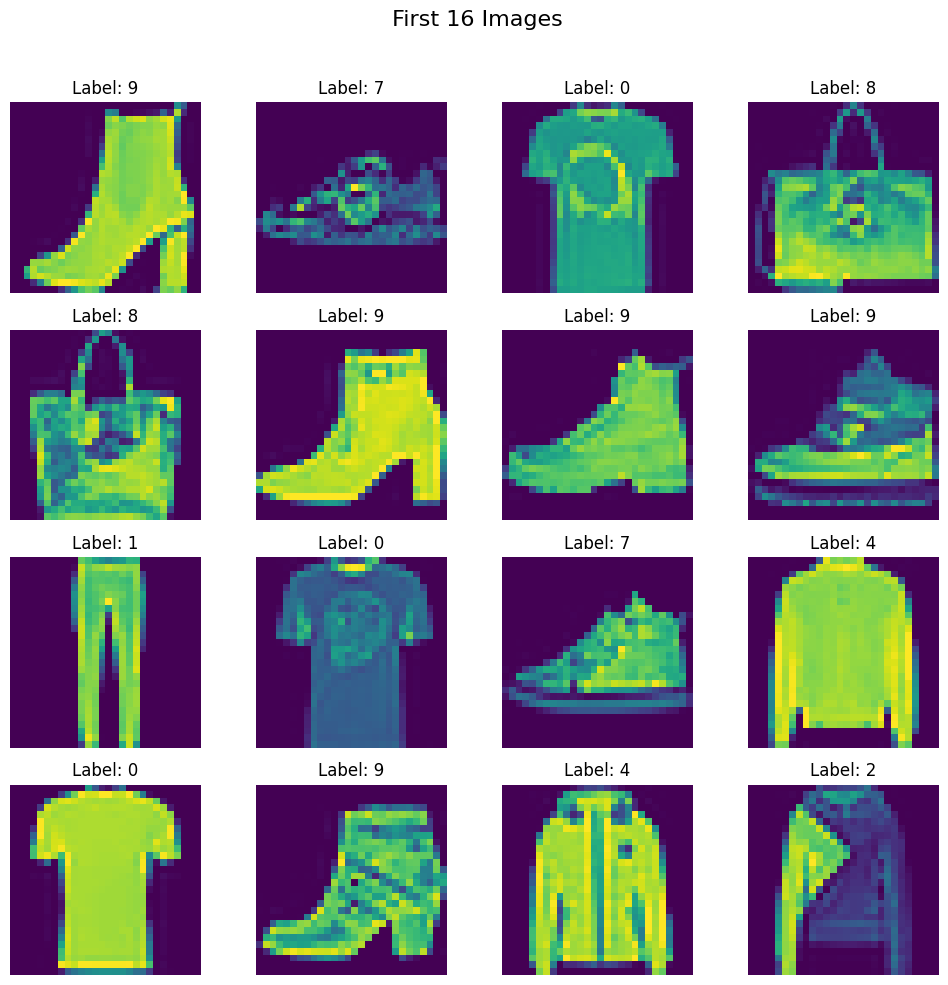

In [28]:
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle(" First 16 Images" , fontsize=16)

for i,ax in enumerate(axes.flat):
    img = df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label: {df.iloc[i,0]}")
    

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


In [29]:
x = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [30]:
x_train , x_test, y_train , y_test = train_test_split(x,y , test_size=0.2 , random_state=42)

In [31]:
x_train= x_train/255.0
x_test= x_test/255.0

In [32]:
x_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]], shape=(4800, 784))

In [33]:
class CustomDataset(Dataset):
    
    def __init__(self, features , labels):
        
        self.features = torch.tensor(features , dtype=torch.float32)
        self.labels = torch.tensor(labels , dtype=torch.long)
        
    def __len__(self):
        return self.features.shape[0]
    
    def __getitem__(self, index):
        return self.features[index] , self.labels[index]

In [34]:
train_dataset = CustomDataset(x_train, y_train)
test_dataset = CustomDataset(x_test , y_test)

In [35]:
len(train_dataset)

4800

In [36]:
train_loader = DataLoader(train_dataset , batch_size=32 , shuffle=True)
test_loader = DataLoader(test_dataset , batch_size=32 , shuffle=False)

In [37]:
class MyNN(nn.Module):
    
    def __init__(self , num_features):
        
        super().__init__()
        
        self.model= nn.Sequential(
            nn.Linear(num_features,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)# by default internally softmax is implemented
        )
        
        
    def forward(self, x):
        
        return self.model(x)
    

In [38]:
learning_rate = 0.1
epochs = 100

In [39]:
model = MyNN(x_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [40]:

for epoch in range(epochs):
    total_epoch_loss =0 
    for batch_features , batch_labels in train_loader:
        # # Convert to float32 for compatibility with model
        # batch_features = batch_features.float()
        # batch_labels = batch_labels.float()
        
        #forward pass
        y_pred = model(batch_features)
        
        #loss calculate
        loss = criterion(y_pred, batch_labels)
        
        #zero grad for next epoch not needed accumulate for grad
        # It is better to make it zero before calculation than after 
        optimizer.zero_grad()
        #backward pass 
        loss.backward()
        #parameter update
        optimizer.step()
        total_epoch_loss = total_epoch_loss+ loss.item()
        
    print(f"Epoch: {epoch+1} -> Loss: {total_epoch_loss/len(train_loader)}")

Epoch: 1 -> Loss: 1.3216368583838145
Epoch: 2 -> Loss: 0.7793365317583084
Epoch: 3 -> Loss: 0.6427524542808533
Epoch: 4 -> Loss: 0.5751657458146413
Epoch: 5 -> Loss: 0.5278772719701131
Epoch: 6 -> Loss: 0.49531099418799085
Epoch: 7 -> Loss: 0.4619268523653348
Epoch: 8 -> Loss: 0.43578990375002224
Epoch: 9 -> Loss: 0.41821308076381686
Epoch: 10 -> Loss: 0.39949775497118634
Epoch: 11 -> Loss: 0.38570138782262803
Epoch: 12 -> Loss: 0.3719716985026995
Epoch: 13 -> Loss: 0.3493794798851013
Epoch: 14 -> Loss: 0.3455629136164983
Epoch: 15 -> Loss: 0.31592130129535995
Epoch: 16 -> Loss: 0.3110544161498547
Epoch: 17 -> Loss: 0.2934306888779004
Epoch: 18 -> Loss: 0.2854089424510797
Epoch: 19 -> Loss: 0.2734348543733358
Epoch: 20 -> Loss: 0.2617666217436393
Epoch: 21 -> Loss: 0.26644358336925505
Epoch: 22 -> Loss: 0.24347751920421917
Epoch: 23 -> Loss: 0.23926382559041182
Epoch: 24 -> Loss: 0.225456866795818
Epoch: 25 -> Loss: 0.22396456686158975
Epoch: 26 -> Loss: 0.21319957663615544
Epoch: 27 -

In [41]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [42]:
total=0
correct=0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        
        outputs = model(batch_features)##give 32,10 
        
        _, predicted = torch.max(outputs,1)
        
        total = total + batch_labels.shape[0]
        correct = correct + (predicted==batch_labels).sum().item()
        
print(correct/total)

0.7966666666666666
